# 02 · Estrategias, costes y métricas

**Objetivo:** comparar las estrategias frente a buy-and-hold, con y sin costes, y entender qué se come los beneficios.

**Necesitas:** los TODO 1.x, 2.x (motor), 3.x (estrategias) y 4.x (métricas). Checkpoint: `python -m pytest tests/test_backtest.py tests/test_strategies.py tests/test_metrics.py`.

**Teoría:** `docs/02_Motor_de_backtesting.pdf`, `docs/03_Estrategias.pdf` y `docs/04_Metricas.pdf`.

**Cómo usar este notebook.** Ejecuta las celdas en orden. Una celda que llama a una función que todavía es un TODO falla con `NotImplementedError: TODO x.y`: completa ese TODO, pasa su checkpoint de `pytest` y vuelve a ejecutarla (con `autoreload` no hace falta reiniciar el kernel).

Las celdas marcadas **`# TODO (análisis)`** son tuyas y no las corrige ningún test: sirven para mirar los datos y responder a las preguntas. Hasta que las completes no hacen nada (`...`).

In [1]:
# Configuración: localiza la raíz del repo y recarga src/ al guardar cambios (no hace falta reiniciar)
%load_ext autoreload
%autoreload 2

import json
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from src import backtest, config, data, metrics, plotting, strategies, walkforward

plotting.apply_style()
pd.set_option("display.width", 140)

In [2]:
prices = data.load_prices()
params = config.STRATEGY_DEFAULTS
params

{'buy_and_hold': {},
 'sma_crossover': {'fast': 50, 'slow': 200},
 'momentum_12m': {'lookback_months': 12, 'skip_months': 0},
 'bollinger_mean_reversion': {'window': 20, 'n_std': 2.0}}

## 1. Señales

Cada estrategia devuelve una tabla fechas × activos con −1, 0 o 1. Antes de backtestear, mira cuánto tiempo pasa cada una invertida.

In [3]:
signals = {name: strategies.get_strategy(name)(prices, **kw) for name, kw in params.items()}
invested = pd.DataFrame({name: (s != 0).mean() for name, s in signals.items()})
invested.style.format("{:.0%}")

,buy_and_hold,sma_crossover,momentum_12m,bollinger_mean_reversion
SPY,100%,80%,85%,17%
QQQ,100%,82%,86%,17%
IWM,100%,71%,69%,21%
EFA,100%,68%,62%,22%
GLD,100%,60%,59%,21%
TLT,100%,53%,51%,24%
AAPL,100%,74%,77%,18%
MSFT,100%,75%,80%,16%
JPM,100%,74%,73%,20%
XOM,100%,60%,62%,22%


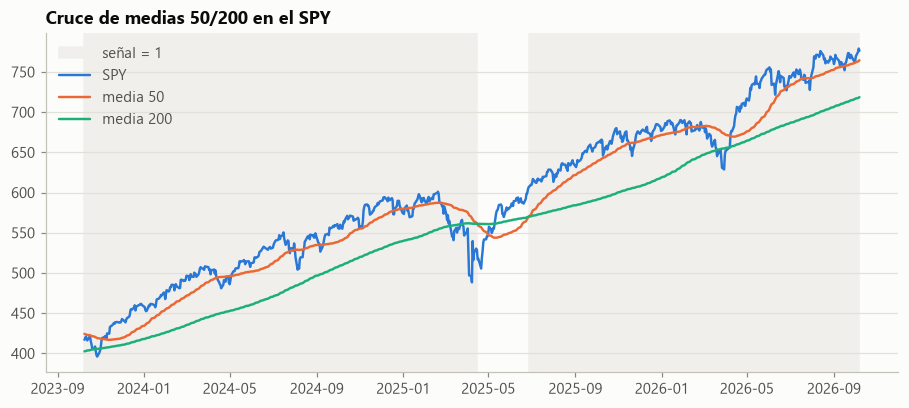

In [4]:
# El cruce de medias en el SPY durante los últimos 3 años (sombreado = invertido)
last = prices.index[-1] - pd.DateOffset(years=3)
close = prices["SPY"]
fast = close.rolling(params["sma_crossover"]["fast"]).mean()
slow = close.rolling(params["sma_crossover"]["slow"]).mean()
signal = signals["sma_crossover"]["SPY"]

fig, ax = plt.subplots(figsize=(10, 4))
window = close.index >= last
ax.fill_between(close.index[window], 0, 1, where=signal[window] > 0, transform=ax.get_xaxis_transform(),
                color=plotting.NEUTRAL_FILL, label="señal = 1")
ax.plot(close[window], color=plotting.PALETTE[0], label="SPY")
ax.plot(fast[window], color=plotting.PALETTE[1], label="media 50")
ax.plot(slow[window], color=plotting.PALETTE[2], label="media 200")
ax.set_title("Cruce de medias 50/200 en el SPY")
ax.legend(loc="upper left");

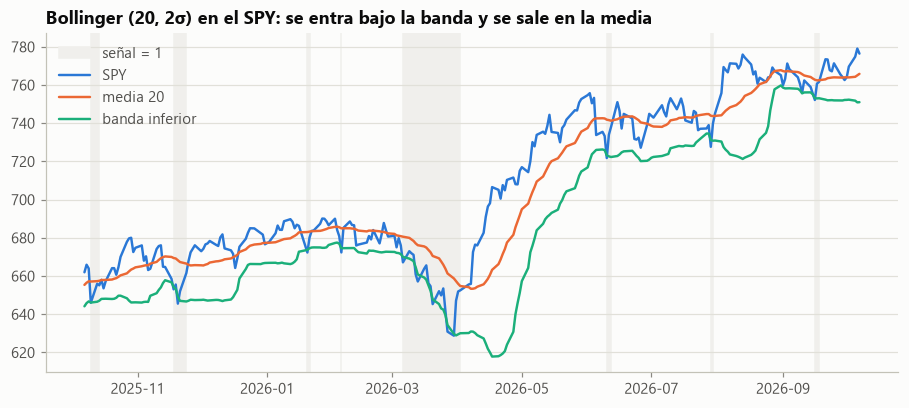

In [5]:
# Bandas de Bollinger en el SPY durante el último año, con la señal (estrategia con estado)
last = prices.index[-1] - pd.DateOffset(years=1)
kw = params["bollinger_mean_reversion"]
mid = close.rolling(kw["window"]).mean()
band = kw["n_std"] * close.rolling(kw["window"]).std()
signal = signals["bollinger_mean_reversion"]["SPY"]

fig, ax = plt.subplots(figsize=(10, 4))
window = close.index >= last
ax.fill_between(close.index[window], 0, 1, where=signal[window] > 0, transform=ax.get_xaxis_transform(),
                color=plotting.NEUTRAL_FILL, label="señal = 1")
ax.plot(close[window], color=plotting.PALETTE[0], label="SPY")
ax.plot(mid[window], color=plotting.PALETTE[1], label="media 20")
ax.plot((mid - band)[window], color=plotting.PALETTE[2], label="banda inferior")
ax.set_title("Bollinger (20, 2σ) en el SPY: se entra bajo la banda y se sale en la media")
ax.legend(loc="upper left");

## 2. Backtests con y sin costes

In [6]:
results = {name: backtest.run_backtest(prices, s) for name, s in signals.items()}
gross = {name: backtest.run_backtest(prices, s, commission_bps=0, slippage_bps=0) for name, s in signals.items()}
results["sma_crossover"]

BacktestResult(2010-01-04 a 2026-10-07, 4216 días, 10 activos, equity final 4.588)

## 3. Tabla comparativa

In [7]:
table_net = metrics.summary_table(results)
table_gross = metrics.summary_table(gross)
print("Con costes (5 + 5 bps)")
display(metrics.format_summary(table_net))
print("Sin costes")
display(metrics.format_summary(table_gross))

Con costes (5 + 5 bps)


,CAGR,Vol.,Sharpe,Sortino,Max DD,Calmar,Hit ratio,Turnover anual
Estrategia,,,,,,,,
buy_and_hold,14.6%,14.6%,1.01,1.44,-28.3%,0.52,55.1%,0.1×
sma_crossover,9.5%,10.4%,0.93,1.29,-22.9%,0.42,55.6%,1.2×
momentum_12m,9.0%,10.8%,0.85,1.19,-20.4%,0.44,55.6%,1.2×
bollinger_mean_reversion,4.1%,9.1%,0.49,0.71,-25.0%,0.17,51.0%,8.5×


Sin costes


,CAGR,Vol.,Sharpe,Sortino,Max DD,Calmar,Hit ratio,Turnover anual
Estrategia,,,,,,,,
buy_and_hold,14.6%,14.6%,1.01,1.44,-28.3%,0.52,55.1%,0.1×
sma_crossover,9.7%,10.4%,0.94,1.30,-22.9%,0.42,55.7%,1.2×
momentum_12m,9.1%,10.8%,0.86,1.21,-20.4%,0.45,55.6%,1.2×
bollinger_mean_reversion,5.0%,9.1%,0.58,0.85,-24.6%,0.20,53.8%,8.5×


El README pide verificar el Sharpe contra `quantstats`. Las diferencias deberían ser prácticamente 0 (el test exige menos de 1e-10):

In [8]:
metrics.compare_with_quantstats(results["sma_crossover"])

,propia,quantstats,diferencia
Sharpe,0.931421,0.931421,0.0
Sortino,1.287892,1.287892,0.0
Volatilidad,0.103561,0.103561,0.0
Max DD,-0.229452,-0.229452,0.0


In [9]:
# TODO (análisis): ¿cuadran los costes?
# Coste anual aproximado ≈ turnover anual × (comisión + slippage) / 10 000.
# Compáralo, por estrategia, con la diferencia CAGR sin costes − CAGR con costes.
# Pista: las columnas "Turnover anual" y "CAGR" de table_net y table_gross.
turnover = table_net["Turnover anual"]
cagr_gross = table_gross["CAGR"]
cagr_net = table_net["CAGR"]

coste_anual_aprox = turnover * (config.COMMISSION_BPS + config.SLIPPAGE_BPS) / 10000
coste_real = cagr_gross - cagr_net

cost_check = pd.DataFrame({
    "Turnover anual": turnover,
    "Coste estimado": coste_anual_aprox,
    "Coste Real": coste_real,
    "Diferencia Costes": coste_real - coste_anual_aprox,
})
cost_check.style.format({"Diferencia Costes": "{:.3%}"})

,Turnover anual,Coste estimado,Coste Real,Diferencia Costes
Estrategia,,,,
buy_and_hold,0.059772,0.000060,0.000068,0.001%
sma_crossover,1.219355,0.001219,0.001337,0.012%
momentum_12m,1.207400,0.001207,0.001314,0.011%
bollinger_mean_reversion,8.493643,0.008494,0.008885,0.039%


## 4. Equity y drawdown

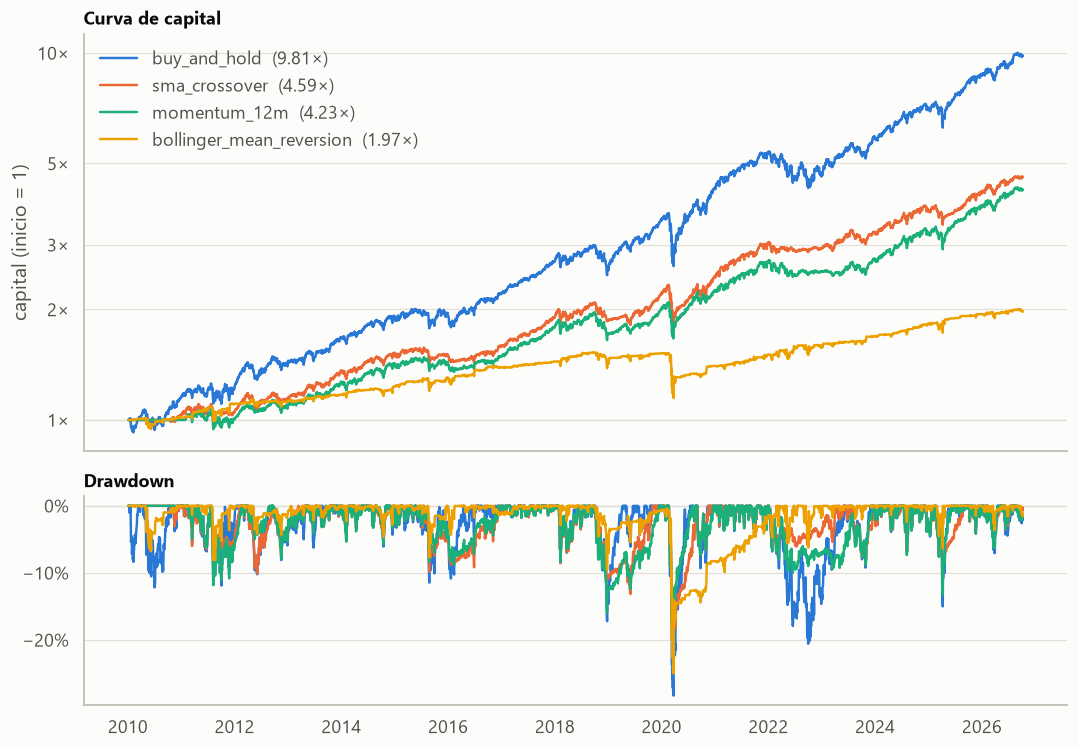

In [10]:
plotting.plot_equity_and_drawdown(results);

In [11]:
for name, res in results.items():
    print(f"{name:26} {metrics.max_drawdown(res)}")

buy_and_hold               Max DD -28.3%  pico 2020-02-19  valle 2020-03-23  recuperación 2020-07-15
sma_crossover              Max DD -22.9%  pico 2020-02-19  valle 2020-03-23  recuperación 2020-09-01
momentum_12m               Max DD -20.4%  pico 2020-02-19  valle 2020-03-23  recuperación 2020-07-31
bollinger_mean_reversion   Max DD -25.0%  pico 2018-09-28  valle 2020-03-23  recuperación 2022-02-25


## 5. Impacto de los costes

Las estrategias de reversión a la media operan mucho. ¿Cuánto coste aguantan?

In [12]:
# TODO (análisis): Sharpe de cada estrategia con costes totales de 0, 5, 10, 20, 30 y 50 bps.
# Reparte cada coste a partes iguales entre comisión y slippage (solo importa la suma).
# Resultado: DataFrame con índice = bps (llámalo "bps") y una columna por estrategia.
costs_bps = [0, 5, 10, 20, 30, 50]
columns = {}
for name, s in signals.items():
    sharpes = []
    for b in costs_bps:
        result = backtest.run_backtest(prices, s, commission_bps=b / 2, slippage_bps=b / 2)
        sharpes.append(metrics.sharpe_ratio(result))
    columns[name] = sharpes
sensitivity = pd.DataFrame(columns, index=pd.Index(costs_bps, name="bps"))
sensitivity

,buy_and_hold,sma_crossover,momentum_12m,bollinger_mean_reversion
bps,,,,
0,1.006612,0.943243,0.860886,0.583401
5,1.006410,0.937333,0.855390,0.536826
10,1.006209,0.931421,0.849888,0.490244
20,1.005803,0.919588,0.838864,0.397078
30,1.005394,0.907745,0.827816,0.303952
50,1.004569,0.884030,0.805651,0.118014


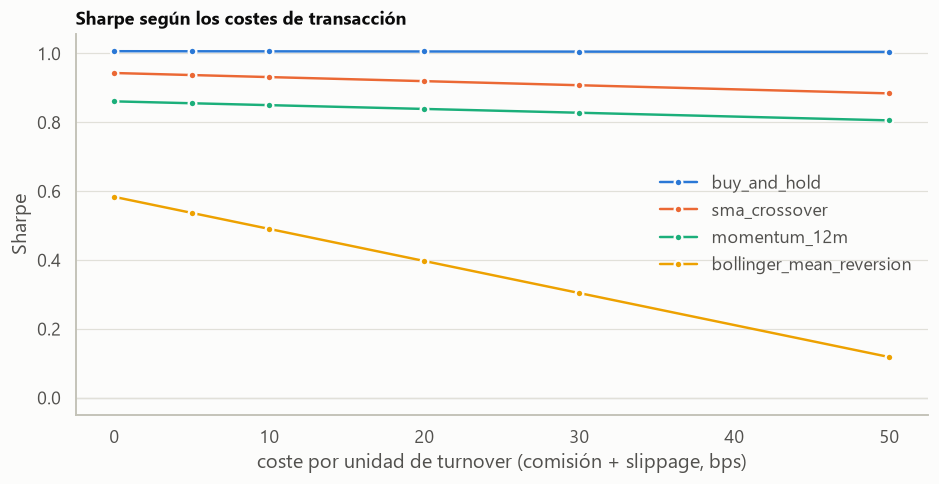

In [13]:
# Se dibuja cuando hayas completado la celda anterior
if isinstance(sensitivity, pd.DataFrame):
    plotting.plot_cost_sensitivity(sensitivity)

> **Preguntas.** ¿A partir de cuántos bps deja de compensar Bollinger frente a buy-and-hold? ¿Qué columna de la tabla comparativa lo predecía? ¿Son realistas 5 + 5 bps para un ETF líquido? ¿Y para una acción pequeña?

## 6. Variantes (opcional)

In [14]:
# TODO (análisis): compara variantes de las estrategias con summary_table + format_summary:
#   - momentum 12-0 frente a 12-1 (skip_months=1)
#   - cruce de medias solo largo frente a largo/corto (allow_short=True)
# ¿Mejora alguna variante de forma clara, o las diferencias son pequeñas comparadas con el ruido?

variants = {
    "momentum 12-0": results["momentum_12m"],
    "momentum 12-1": backtest.run_backtest(prices, strategies.momentum_12m(prices, skip_months=1)),
    "sma solo largo": results["sma_crossover"],
    "sma largo/corto": backtest.run_backtest(prices, strategies.sma_crossover(prices, allow_short=True)),
}
metrics.format_summary(metrics.summary_table(variants))


,CAGR,Vol.,Sharpe,Sortino,Max DD,Calmar,Hit ratio,Turnover anual
Estrategia,,,,,,,,
momentum 12-0,9.0%,10.8%,0.85,1.19,-20.4%,0.44,55.6%,1.2×
momentum 12-1,8.9%,11.4%,0.80,1.13,-23.4%,0.38,55.7%,1.3×
sma solo largo,9.5%,10.4%,0.93,1.29,-22.9%,0.42,55.6%,1.2×
sma largo/corto,4.7%,10.9%,0.47,0.64,-22.2%,0.21,54.0%,2.4×


## 7. Extensión: volatility targeting (TODO 6.1)

`run_backtest(..., vol_target=0.10)` escala la posición de cada activo para apuntar a un 10 % de volatilidad anual. Teoría: `docs/06_Volatility_targeting.pdf`.

In [15]:
# TODO (análisis): compara buy_and_hold y sma_crossover con y sin vol_target=0.10.
# ¿Qué cambia más: el CAGR, la volatilidad, el drawdown o el Sharpe? ¿Por qué?

vol_targeted = {
    "buy_and_hold": results["buy_and_hold"],
    "buy_and_hold vol 10%": backtest.run_backtest(prices, signals["buy_and_hold"], vol_target=0.10),
    "sma_crossover": results["sma_crossover"],
    "sma_crossover vol 10%": backtest.run_backtest(prices, signals["sma_crossover"], vol_target=0.10),
}
metrics.format_summary(metrics.summary_table(vol_targeted))

,CAGR,Vol.,Sharpe,Sortino,Max DD,Calmar,Hit ratio,Turnover anual
Estrategia,,,,,,,,
buy_and_hold,14.6%,14.6%,1.01,1.44,-28.3%,0.52,55.1%,0.1×
buy_and_hold vol 10%,6.6%,6.7%,1.00,1.39,-11.6%,0.57,55.5%,2.0×
sma_crossover,9.5%,10.4%,0.93,1.29,-22.9%,0.42,55.6%,1.2×
sma_crossover vol 10%,4.9%,5.5%,0.90,1.23,-10.0%,0.49,55.4%,2.2×


## 8. Preguntas de reflexión

1. ¿Alguna estrategia bate a buy-and-hold en CAGR? ¿Y en Sharpe o en drawdown? ¿Qué preferirías y por qué?
2. La cartera es equiponderada entre 10 activos muy distintos (TLT, GLD, AAPL...). ¿Cómo afecta eso a la comparación?
3. Estos parámetros (50/200, 20 días y 2σ) son los "de libro", no los optimizados. ¿Por qué eso hace que esta tabla sea más creíble que una con parámetros ajustados? (Lo verás en el notebook 03.)
4. ¿Qué limitaciones del README afectan más a cada estrategia? Piensa en los cortos sin coste de préstamo y en el slippage fijo.